In [4]:
# 2025.11.30 Ensemble Set

In [1]:
import os
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import time
import math
import shap
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import accuracy_score, f1_score
from sklearn.metrics         import roc_auc_score, roc_curve
from sklearn.metrics         import classification_report, confusion_matrix
from sklearn.metrics         import recall_score, precision_score
from sklearn.metrics         import classification_report, precision_recall_curve
from sklearn.datasets        import make_classification
from sklearn.preprocessing   import RobustScaler

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import StackingClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.linear_model   import SGDClassifier
from sklearn.svm            import SVC
from sklearn.svm            import LinearSVC
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP
import utils.data_sampling  as ds

import importlib

from utils import hyperopt_search
importlib.reload(hyperopt_search)
from utils import user_utils
importlib.reload(user_utils)

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [3]:
# -------------------------------------------------------
# 🔷 모델 생성 함수 (HyperOpt 파라미터 자동 적용)
# -------------------------------------------------------

def get_models():
    models = {
        "cat": CatBoostClassifier(**HP.cb_best_params),
        "dt": DecisionTreeClassifier(**HP.dt_basic_params),
        "gb": GradientBoostingClassifier(**HP.gb_best_params),
        "hgb": HistGradientBoostingClassifier(**HP.hgb_best_params),
        "lgbm": LGBMClassifier(**HP.lgbm_best_param2),
        "lr": LogisticRegression(**HP.lr_best_params),
        "lir" : LinearRegression(**HP.lir_best_params),
        "lsvc": LinearSVC(**HP.lsvc_best_params),
        "mlp": MLPClassifier(**HP.mlp_basic_params),
        "rf": RandomForestClassifier(**HP.rf_best_params),
        "sgd": SGDClassifier(**HP.sgd_best_params),
        "svm_rbf": SVC(**HP.svc_rbf_best_params),
        "xgb": XGBClassifier(**HP.xgb_best_params, eval_metric='logloss'),
    }

    return models
# eof ----------------------------------------------------------------

In [4]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [5]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [6]:
# 2. 데이터 전처리
# 2.1 Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')
X_features.shape, y_target.shape

((284807, 29), (284807,))

In [7]:
# 2.2 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [8]:
# 2.3 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [13]:
# 학습/검증 데이터 분리
# X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [9]:
# 2.4 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)


✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [ ]:
# Over Sampling한 경우 학습/검증 데이터 분리
# X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

In [ ]:
# 사용자 Functions import - 에러나서 다시 실행
# import importlib
# from utils import hyperopt_search
# importlib.reload(hyperopt_search)

# from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [10]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기
# 2.5 StandardScaler 적용
X_train_sscaled, X_test_sscaled, scaler = pp.scale_data(X_train, X_test)

In [11]:
# 2.6 robustScaler 적용

rscaler = RobustScaler()
X_train_rscaled = rscaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = rscaler.transform(X_test)         # 테스트 데이터는 transform만

In [ ]:
# 1️⃣ **Hard Voting - 다양성 극대화 조합** (claude 추천 1순위)
# ensemble_1 = {
#     'name': 'Diverse Hard Voting',
#     'method': 'VotingClassifier (hard)',
#     'models': [
#         'XGBoost',           # Tree-based, scale_pos_weight
#         'LightGBM',          # Tree-based, 빠른 학습
#         'LogisticRegression', # Linear, SMOTE
#         'SGD',               # Linear, 원본 데이터
#         'RandomForest'       # Bagging 기반
#     ],
#     'voting': 'hard',
#     'weights': None,
#     'reason': '다양한 알고리즘 타입(Boosting, Linear, Bagging) 혼합으로 편향 최소화'
# }
# 구현 예시
from sklearn.ensemble import VotingClassifier

ensemble_1_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('lr', lr_model),
        ('sgd', sgd_model),
        ('rf', rf_model)
    ],
    voting='hard'
)

ensemble_1_model.fit(X_train, y_train)
y_pred = ensemble_1_model.predict(X_test)

In [ ]:
# 2️⃣ **Soft Voting - 확률 기반 앙상블**
# ensemble_2 = {
#     'name': 'Probability Weighted Soft Voting',
#     'method': 'VotingClassifier (soft)',
#     'models': [
#         'CatBoost',          # 높은 AUC 성능
#         'XGBoost',           # robust boosting
#         'LightGBM',          # 빠른 수렴
#         'LogisticRegression', # 확률 calibration 우수
#         'MLPClassifier'      # 비선형 패턴 학습
#     ],
#     'voting': 'soft',
#     'weights': [1.2, 1.2, 1.1, 1.0, 0.9],  # 성능 기반 가중치
#     'reason': '확률 기반 투표로 불확실성 처리, 고성능 모델에 가중치 부여'
# }
# 구현 예시
ensemble_2_model = VotingClassifier(
    estimators=[
        ('catboost', catboost_model),
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('lr', lr_model),
        ('mlp', mlp_model)
    ],
    voting='soft',
    weights=[1.2, 1.2, 1.1, 1.0, 0.9]
)

ensemble_2_model.fit(X_train, y_train)
y_proba = ensemble_2_model.predict_proba(X_test)[:, 1]

In [ ]:
# 3️⃣ **Stacking - 2-Level Meta Learner**
# ensemble_3 = {
#     'name': 'Two-Level Stacking',
#     'method': 'StackingClassifier',
#     'base_models': [
#         'CatBoost',          # Level 1
#         'XGBoost',           # Level 1
#         'LightGBM',          # Level 1
#         'RandomForest',      # Level 1
#         'SVM_rbf',         # Level 1 - 비선형 경계
#         'SGD'                # Level 1 - 선형 경계
#     ],
#     'meta_model': 'LogisticRegression (kjh)',  # Level 2
#     'cv': 5,
#     'reason': 'Base 모델들의 예측을 meta-learner가 학습하여 최적 조합 발견'
# }
# 구현 예시
from sklearn.ensemble import StackingClassifier

ensemble_3_model = StackingClassifier(
    estimators=[
        ('catboost', catboost_model),
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('rf', rf_model),
        ('svm', svm_rbf_model),
        ('sgd', sgd_model)
    ],
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,
    stack_method='predict_proba'
)

ensemble_3_model.fit(X_train, y_train)
y_pred = ensemble_3_model.predict(X_test)

In [ ]:
# 4️⃣ **Boosting 특화 앙상블**
# ensemble_4 = {
#     'name': 'Boosting Power Ensemble',
#     'method': 'Weighted Average (Custom)',
#     'models': [
#         'CatBoost',          # 범주형 변수 강점
#         'XGBoost',           # 고속 학습
#         'LightGBM',          # 메모리 효율
#         'GradientBoosting'   # sklearn 안정성
#     ],
#     'weights': [0.30, 0.30, 0.25, 0.15],  # AUC 기준 가중치
#     'threshold': 0.3,  # 사기 탐지 임계값 조정
#     'reason': 'Boosting 계열만으로 구성, 순차 학습의 강점 극대화'
# }
# 구현 예시

# 각 모델의 확률 예측
catboost_proba = catboost_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]
gb_proba = gb_model.predict_proba(X_test)[:, 1]

# 가중 평균
weights = [0.30, 0.30, 0.25, 0.15]
ensemble_4_proba = (
    weights[0] * catboost_proba +
    weights[1] * xgb_proba +
    weights[2] * lgbm_proba +
    weights[3] * gb_proba
)

# 임계값 조정 (사기 탐지 최적화)
threshold = 0.3
y_pred = (ensemble_4_proba >= threshold).astype(int)

In [ ]:
# 5️⃣ **Hybrid - Tree + Linear 균형 조합**
# ensemble_5 = {
#     'name': 'Tree-Linear Hybrid Voting',
#     'method': 'VotingClassifier (soft)',
#     'models': [
#         # Tree 기반 (60%)
#         'XGBoost',           # 20%
#         'LightGBM',          # 20%
#         'RandomForest',      # 20%

#         # Linear 기반 (40%)
#         'LogisticRegression', # 20%
#         'SGD',               # 10%
#         'lsvc'       # 10%
#     ],
#     'voting': 'soft',
#     'weights': [1.2, 1.2, 1.2, 1.0, 0.8, 0.8],
#     'reason': 'Tree의 비선형 포착 + Linear의 일반화 능력 결합'
# }

### ChatGpt 추천 조합

| 조합 번호 | 구성                         | 특징              |
| ----- | -------------------------- | --------------- |
| **1** | CatBoost + XGB + LGBM + LR | 성능 최상위 전천후      |
| **2** | LGBM + RF + MLP            | 구조적 다양성 최고      |
| **3** | CatBoost + GB + SVM(RBF)   | Recall 최적화      |
| **4** | XGB + LR + SVM(linear)     | 단순·안정·일관된 결정 경계 |
| **5** | RF + SGD + MLP + LR        | 전통 ML 메타 스택     |

In [ ]:
# ===========================================================
# 2. Base Models (HyperOpt 결과 삽입)
# ===========================================================

# HP 이용

# Meta Model
# meta_model = LogisticRegression(max_iter=2000)


# ===========================================================
# 3. Stacking 함수 직접 작업할때 예시
# ===========================================================
# def stacking_predict(X_train, y_train, X_test, n_folds=5):

#     kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

#     # Level-1 예측값 저장
#     oof_cat, oof_xgb, oof_lgb = (
#         np.zeros(len(X_train)),
#         np.zeros(len(X_train)),
#         np.zeros(len(X_train)),
#     )
#     test_cat, test_xgb, test_lgb = (
#         np.zeros(len(X_test)),
#         np.zeros(len(X_test)),
#         np.zeros(len(X_test)),
#     )

#     for fold, (trn_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#         print(f"Fold {fold+1}/{n_folds}")

#         X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
#         y_tr, y_val = y_train.iloc[trn_idx], y_train.iloc[val_idx]

#         # ---------------------------------------------------
#         # CatBoost
#         # ---------------------------------------------------
#         model_cat = CatBoostClassifier(**cat_params)
#         model_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)

#         oof_cat[val_idx] = model_cat.predict_proba(X_val)[:, 1]
#         test_cat += model_cat.predict_proba(X_test)[:, 1] / n_folds

#         # ---------------------------------------------------
#         # XGBoost
#         # ---------------------------------------------------
#         model_xgb = XGBClassifier(**xgb_params)
#         model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

#         oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
#         test_xgb += model_xgb.predict_proba(X_test)[:, 1] / n_folds

#         # ---------------------------------------------------
#         # LightGBM
#         # ---------------------------------------------------
#         model_lgb = LGBMClassifier(**lgbm_params)
#         model_lgb.fit(X_tr, y_tr,
#                       eval_set=[(X_val, y_val)],
#                       verbose=False)

#         oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
#         test_lgb += model_lgb.predict_proba(X_test)[:, 1] / n_folds

#     # =======================================================
#     # Meta Model 학습
#     # =======================================================
#     train_meta = np.vstack([oof_cat, oof_xgb, oof_lgb]).T
#     test_meta = np.vstack([test_cat, test_xgb, test_lgb]).T

#     scaler = StandardScaler()
#     train_meta_scaled = scaler.fit_transform(train_meta)
#     test_meta_scaled = scaler.transform(test_meta)

#     meta_model.fit(train_meta_scaled, y_train)
#     meta_oof = meta_model.predict_proba(train_meta_scaled)[:, 1]

#     print("Stacking Level-2 AUC:", roc_auc_score(y_train, meta_oof))

#     return test_meta_scaled, meta_model


# ===========================================================
# 4. 실행 예시
# ===========================================================
# X_train, y_train, X_test는 이미 로딩된 상태라고 가정
# final_test_meta, final_meta_model = stacking_predict(X_train, y_train, X_test)


In [12]:
def create_lr(best_params):
    """
    LogisticRegression 모델을 HyperOpt/Optuna로 찾은 best_params 기반으로 생성하는 함수.

    이 함수는 LogisticRegression의 solver와 penalty 조합이 유효한지 검사하고,
    유효하지 않은 조합이 들어올 경우 자동으로 수정하여 안전하게 모델을 생성한다.

    Parameters
    ----------
    best_params : dict
        HyperOpt 또는 Optuna로 최적화한 LogisticRegression의 최적 파라미터 딕셔너리.
        예: {"C": 0.1, "solver": "liblinear", "penalty": "l1"}

    Returns
    -------
    LogisticRegression
        최종적으로 검증된 파라미터로 생성된 LogisticRegression 모델.

    Notes
    -----
    - solver에 따라 사용할 수 있는 penalty 종류가 다르기 때문에,
      최적화 결과가 잘못된 조합을 반환할 가능성이 있음.
    - 안전성을 위해 직접 검증한 후 잘못된 penalty는 'l2'로 자동 변경한다.
    - 변경이 발생하면 경고 메시지를 출력한다.
    """

    # 최적화된 solver, penalty 값을 가져오고 기본값 설정
    solver = best_params.get('solver', 'liblinear')
    penalty = best_params.get('penalty', 'l2')

    # solver별로 허용되는 penalty 목록 정의
    valid_penalties = {
        'liblinear': ['l1', 'l2'],
        'lbfgs': ['l2', 'none'],
        'saga': ['l1', 'l2', 'elasticnet', 'none'],
        'newton-cg': ['l2', 'none'],
    }

    # penalty가 solver에 맞지 않으면 자동 수정
    if penalty not in valid_penalties.get(solver, []):
        print(f"[WARN] penalty '{penalty}' is incompatible with solver '{solver}'. Using 'l2'")
        best_params['penalty'] = 'l2'

    # 유효한 파라미터로 LogisticRegression 모델 생성
    return LogisticRegression(**best_params)
# eof -----------------------------------------------------------


In [ ]:
# ======================================
# 🔷 Stacking #1: CatBoost + XGB + LGBM
# ======================================

models = get_models()

estimators_1 = [
    ('cat', models['cat']),
    ('xgb', models['xgb']),
    ('lgbm', models['lgbm']),
]


stack_1 = StackingClassifier(
    estimators=estimators_1,
    final_estimator=create_lr(HP.lr_best_params),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)
option_name = 'cat+xgb+lgbm_ho_best'
results[option_name] = uu.get_model_train_eval(stack_1, f'{option_name}', X_train, X_test, y_train, y_test)


In [ ]:
# ======================================
# 🔷 Stacking #2: LGBM + RF + MLP
# ======================================

models = get_models()

estimators_2 = [
    ('lgbm', models['lgbm']),
    ('rf', models['rf']),
    ('mlp', models['mlp']),
]

stack_2 = StackingClassifier(
    estimators=estimators_2,
    final_estimator=create_lr(HP.lr_best_params),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)
option_name = 'lgbm+rf+mlp_ho_best'
results[option_name] = uu.get_model_train_eval(stack_2, f'{option_name}', X_train, X_test, y_train, y_test)


In [13]:
# ======================================
# 🔷 Stacking #3: CatBoost + GB + SVM(RBF)
# ======================================

models = get_models()

estimators_3 = [
    ('cat', models['cat']),
    ('gb', models['gb']),
    ('svm_rbf', models['svm_rbf']),
]

stack_3 = StackingClassifier(
    estimators=estimators_3,
    final_estimator=create_lr(HP.lr_best_params),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

option_name = 'cat+gb+svm_rbf_ho_best'

results[option_name] = uu.get_model_train_eval(stack_3, f'{option_name}', X_train_sscaled, X_test_sscaled, y_train, y_test)


🚀 모델 학습 시작: cat+gb+svm_rbf_ho_best


cat+gb+svm_rbf_ho_best - 평가 중:  50%|████████████▌            | 2/4 [2:37:28<2:11:00, 3930.05s/it]/s]

folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'result_dict': {'AUC': 0.9702, '정확도': 0.9956, '정밀도': 0.2642, '재현율': 0.8571, 'F1': 0.4038, 'F2': 0.5915}, '오차행렬': [[56630, 234], [14, 84]], '실행 시간': 9448.3254}

📊 Base Estimators 평가 중 (3개)...


cat+gb+svm_rbf_ho_best - 저장 중: 100%|███████████████████████████| 4/4 [2:41:13<00:00, 2418.34s/it]

✓ 모델 저장 완료: ../models\cat+gb+svm_rbf_ho_best.pkl
  파일 크기: 6.02 MB

✅ 완료: cat+gb+svm_rbf_ho_best (실행시간: 9448.33초)



In [14]:
def threshold_tuning_model(model, X_test, y_test, model_name="model"):
    """
    predict_proba를 지원하는 이진 분류 모델에 대해
    threshold별 Precision / Recall / F1 / AUC를 계산하고,
    상위 F1 threshold를 보여주는 함수.
    """
    # 1) 예측 확률 (양성 클래스 1에 대한 확률)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 2) threshold grid 정의
    thresholds = np.arange(0.01, 0.91, 0.01)
    rows = []

    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)

        prec = precision_score(y_test, y_pred_thr, zero_division=0)
        rec  = recall_score(y_test, y_pred_thr, zero_division=0)
        f1   = f1_score(y_test, y_pred_thr, zero_division=0)
        auc  = roc_auc_score(y_test, y_proba)  # threshold와 무관하지만 같이 넣어둠

        rows.append({
            "threshold": thr,
            "precision": prec,
            "recall":    rec,
            "f1":        f1,
            "auc":       auc,
        })

    df_thr = pd.DataFrame(rows)

    # 3) F1 기준 상위 threshold 10개
    print(f"\n==== [{model_name}] F1 기준 상위 10개 threshold ====")
    print(
        df_thr.sort_values("f1", ascending=False)
              .head(10)
              .reset_index(drop=True)
    )

    # 4) (옵션) recall ≥ 0.8 구간 중 F1 상위 10개
    high_recall = df_thr[df_thr["recall"] >= 0.8]
    if not high_recall.empty:
        print(f"\n==== [{model_name}] recall ≥ 0.8 구간에서 F1 상위 10개 ====")
        print(
            high_recall.sort_values("f1", ascending=False)
                       .head(10)
                       .reset_index(drop=True)
        )
    else:
        print(f"\n[{model_name}] recall ≥ 0.8 인 threshold가 없음")

    # 5) Precision-Recall vs Threshold 곡선
    precisions, recalls, thr_pr = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(8, 5))
    plt.plot(thr_pr, precisions[:-1], "b--", label="Precision")
    plt.plot(thr_pr, recalls[:-1],    "g-",  label="Recall")
    plt.title(f"{model_name} - Threshold vs Precision/Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    return df_thr


==== [STACK_cat_gb_svmrbf] F1 기준 상위 10개 threshold ====
   threshold  precision    recall        f1       auc
0       0.90   0.389671  0.846939  0.533762  0.970188
1       0.89   0.380734  0.846939  0.525316  0.970188
2       0.88   0.373874  0.846939  0.518750  0.970188
3       0.87   0.370536  0.846939  0.515528  0.970188
4       0.86   0.368889  0.846939  0.513932  0.970188
5       0.85   0.364035  0.846939  0.509202  0.970188
6       0.84   0.360515  0.857143  0.507553  0.970188
7       0.83   0.355932  0.857143  0.502994  0.970188
8       0.82   0.350000  0.857143  0.497041  0.970188
9       0.80   0.345679  0.857143  0.492669  0.970188

==== [STACK_cat_gb_svmrbf] recall ≥ 0.8 구간에서 F1 상위 10개 ====
   threshold  precision    recall        f1       auc
0       0.90   0.389671  0.846939  0.533762  0.970188
1       0.89   0.380734  0.846939  0.525316  0.970188
2       0.88   0.373874  0.846939  0.518750  0.970188
3       0.87   0.370536  0.846939  0.515528  0.970188
4       0.86   0.36

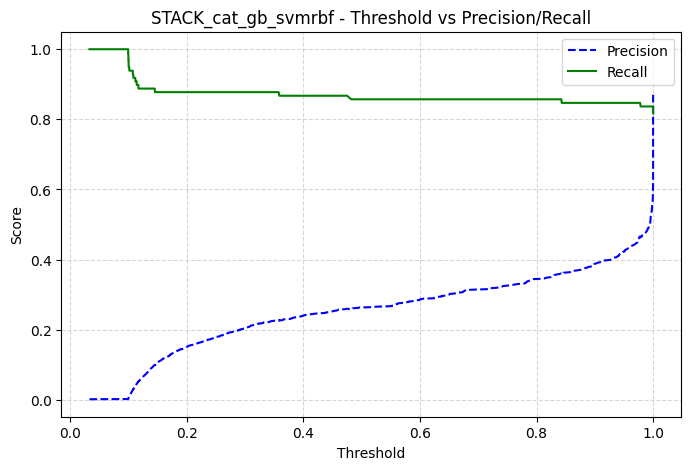

In [15]:
df_thr_stack3 = threshold_tuning_model(
    model=stack_3,
    X_test=X_test_sscaled,
    y_test=y_test,
    model_name="STACK_cat_gb_svmrbf"
)

In [ ]:
# ======================================
# 🔷 Stacking #4: XGB + LR + SVM(linear)
# ======================================

# LR은 메타모델로 사용하는 게 더 좋아서 base에는 넣지 않음

models = get_models()

est_lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    class_weight='balanced'
)

estimators_4 = [
    ('xgb', models['xgb']),
    ('lsvc', create_calibrated_lsvc(models['lsvc'])),
]

stack_4 = StackingClassifier(
    estimators=estimators_4,
    final_estimator=est_lr,
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

option_name = 'stack4(xgb+lsvc+lr)_ho_best'
# results = uu.get_model_train_eval(stack_4, f'{option_name}', X_train, X_test, y_train, y_test)


In [ ]:
# ======================================
# 🔷 Stacking #5: RF + SGD + MLP + LR
# ======================================

estimators_5 = [
    ('rf', models['rf']),
    ('sgd', models['sgd']),
    ('mlp', models['mlp']),
]

stack_5 = StackingClassifier(
    estimators=estimators_5,
    # final_estimator=LogisticRegression(class_weight='balanced', solver='liblinear'),
    final_estimator=create_lr(HP.lr_best_params),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

In [30]:
# ===========================================
# 🔷 5개 Stack 모델을 Soft Voting으로 결합
# ===========================================

from sklearn.ensemble import VotingClassifier

# VotingClassifier는 원래 predict_proba를 지원하는 모델만 가능
# 우리 스택 모델들은 모두 predict_proba 지원하므로 문제 없음
weights_desc = '''
| 스택                         | 추천 이유     | weight |
| -------------------------- | --------- | ------ |
| Stack #1 (Boosting+LR)     | 대부분 최고 성능 | **3**  |
| Stack #3 (CatBoost+GB+SVM) | Recall 강함 | **2**  |
| Stack #2 (LGBM+RF+MLP)     | 안정적       | **2**  |
| Stack #4 (XGB+LR+SVM)      | 선형 경계 보정  | **1**  |
| Stack #5 (RF+SGD+MLP)      | 편향 다양성 확보 | **1**  |
'''

voting_ensemble = VotingClassifier(
    estimators=[
        ('stack1', stack_1),
        ('stack2', stack_2),
        ('stack3', stack_3),
        ('stack4', stack_4),
        ('stack5', stack_5),
    ],
    voting='soft',          # 🔥 중요: 확률 기반 soft voting
    weights=[3, 2, 2, 1, 1], # 가중치
    n_jobs=-1
)

NameError: name 'stack_1' is not defined

In [ ]:
# 시각화
mo.model_metrics_graph(results, 'LGBM 데이터별 성능지표 비교')